In [ ]:
# https://drive.google.com/file/d/1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8/view?usp=sharing

In [ ]:
pip install gdown

In [ ]:
# Download the zip file from Google Drive
import gdown
import os

# link: https://drive.google.com/file/d/1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL/view?usp=sharing
file_id = '1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL
From (redirected): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL&confirm=t&uuid=8183045e-e415-4b7c-b41b-f8d06ea44f87
To: /content/archive.zip
100%|██████████| 1.27G/1.27G [01:31<00:00, 13.8MB/s]


'archive.zip'

In [ ]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [ ]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.config', 'train', 'archive.zip', 'test', 'sample_data']


splitting data

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transformation

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root='train', transform=transform)

In [ ]:
# Split the full_dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [ ]:
from collections import Counter

# Count classes in train_dataset
train_class_counts = Counter()
for _, labels in train_loader:
    train_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Training Set:")
for class_idx, count in sorted(train_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

# Count classes in val_dataset
val_class_counts = Counter()
for _, labels in val_loader:
    val_class_counts.update(labels.cpu().numpy())

print("\nNumber of images per class in Validation Set:")
for class_idx, count in sorted(val_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Training Set:
  Class broadleaf (ID: 0): 665 images
  Class grass (ID: 1): 1943 images
  Class soil (ID: 2): 1813 images
  Class soybean (ID: 3): 4166 images

Number of images per class in Validation Set:
  Class broadleaf (ID: 0): 168 images
  Class grass (ID: 1): 521 images
  Class soil (ID: 2): 461 images
  Class soybean (ID: 3): 997 images


MobilenetV2

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),

    nn.Linear(128, 4)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training loop

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):
    # ---- TRAIN ----
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)

    # ---- F1, Precision, Recall ----
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")
    print(f"F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print("-"*40)


Epoch 1
Train Loss: 0.1711, Train Acc: 0.9420
Val Loss: 0.0689, Val Acc: 0.9753
F1: 0.9752, Precision: 0.9752, Recall: 0.9753
----------------------------------------
Epoch 2
Train Loss: 0.0913, Train Acc: 0.9688
Val Loss: 0.0819, Val Acc: 0.9730
F1: 0.9730, Precision: 0.9742, Recall: 0.9730
----------------------------------------
Epoch 3
Train Loss: 0.0696, Train Acc: 0.9766
Val Loss: 0.0620, Val Acc: 0.9809
F1: 0.9810, Precision: 0.9811, Recall: 0.9809
----------------------------------------
Epoch 4
Train Loss: 0.0516, Train Acc: 0.9817
Val Loss: 0.0559, Val Acc: 0.9790
F1: 0.9788, Precision: 0.9790, Recall: 0.9790
----------------------------------------
Epoch 5
Train Loss: 0.0540, Train Acc: 0.9807
Val Loss: 0.0648, Val Acc: 0.9786
F1: 0.9786, Precision: 0.9789, Recall: 0.9786
----------------------------------------
Epoch 6
Train Loss: 0.0626, Train Acc: 0.9788
Val Loss: 0.0688, Val Acc: 0.9739
F1: 0.9741, Precision: 0.9748, Recall: 0.9739
---------------------------------------

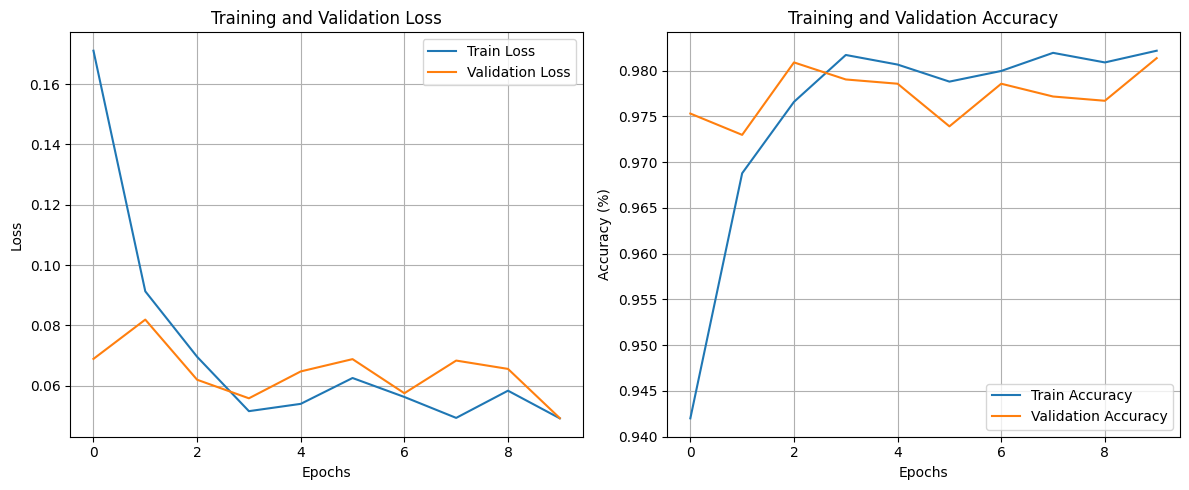

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)



plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
f1 = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print("Final Results:")
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Final Results:
F1 Score: 0.9813127926041678
Precision: 0.9813577550134621
Recall: 0.9813693525850024


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")


Evaluation on Test Data

In [ ]:
test_dataset = datasets.ImageFolder(root='test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

# Count classes in test_dataset
test_class_counts = Counter()
for _, labels in test_loader:
    test_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Test Set:")
for class_idx, count in sorted(test_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Test Set:
  Class broadleaf (ID: 0): 358 images
  Class grass (ID: 1): 1056 images
  Class soil (ID: 2): 975 images
  Class soybean (ID: 3): 2213 images


In [ ]:
evaluate_model(model, test_loader)

Test Loss: 0.0450
Test Accuracy: 98.48%


Latency

In [ ]:
import time

def measure_latency(model, loader, device, num_batches=64):
    model.eval()
    model.to(device)

    total_time = 0
    count = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            start = time.time()
            outputs = model(images)
            end = time.time()

            total_time += (end - start)
            count += 1

            if count >= num_batches:
                break

    avg_latency = total_time / count
    print(f"Average Latency per batch: {avg_latency:.6f} seconds")
    return avg_latency

In [ ]:
measure_latency(model, test_loader, device)

Average Latency per batch: 0.006071 seconds


0.006070621311664581

In [ ]:
import psutil
import os

def measure_ram():
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024**3  # GB
    print(f"RAM Usage: {mem:.4f} GB")
    return mem

In [ ]:
model.to("cpu")
model.eval()

images, _ = next(iter(test_loader))
images = images.to("cpu") # Move images to GPU

measure_ram()
with torch.no_grad():
    outputs = model(images)
measure_ram()

RAM Usage: 1.6253 GB
RAM Usage: 1.6253 GB


1.6252708435058594

In [ ]:
def get_model_size(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1024**2
    print(f"Model size: {size:.2f} MB")
    os.remove("temp.p")
    return size

In [ ]:
get_model_size(model)

Model size: 9.32 MB


9.324097633361816

Quantization

In [ ]:
import torch.quantization

quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},  # only linear layers quantized
    dtype=torch.qint8
)

/tmp/ipykernel_1480/956005537.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [ ]:
device = torch.device("cpu")
model.to(device)
quantized_model.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
quantized_model.to("cpu") # This line is commented out because quantized models typically run on CPU
quantized_model.eval()
# images = images.to("cuda") # The images should also be on CPU if the model is on CPU
images = images.to("cpu")
measure_ram()
with torch.no_grad():
    outputs = quantized_model(images)
measure_ram()

RAM Usage: 1.6253 GB
RAM Usage: 1.6253 GB


1.6252708435058594

In [ ]:
evaluate_model(quantized_model, test_loader)

Test Loss: 0.0477
Test Accuracy: 98.35%


Measurements

In [ ]:
print("FP32 Model:")
measure_latency(model, test_loader, device)
get_model_size(model)

print("\nINT8 Quantized Model:")
measure_latency(quantized_model, test_loader, device)
get_model_size(quantized_model)

FP32 Model:
Average Latency per batch: 0.024476 seconds
Model size: 9.32 MB

INT8 Quantized Model:
Average Latency per batch: 0.016873 seconds
Model size: 8.86 MB


8.855328559875488

Saving the models

In [ ]:
torch.save(model.state_dict(), "model_fp32.pth")

In [ ]:
torch.save(quantized_model.state_dict(), "model_int8.pth")

In [ ]:
from google.colab import files

files.download("model_fp32.pth")
files.download("model_int8.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>